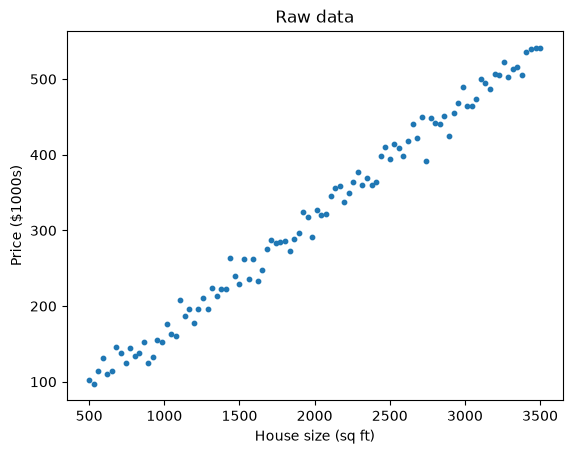

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Fake but realistic data: house size (sq ft, scaled) vs price ($1000s)
np.random.seed(42)
X = np.linspace(500, 3500, 100)          # house size
true_w, true_b = 0.15, 20
noise = np.random.normal(0, 15, size=X.shape)
y = true_w * X + true_b + noise          # price with some randomness

# Normalize X (important: keeps gradient descent stable)
X_norm = (X - X.mean()) / X.std()

plt.scatter(X, y, s=10)
plt.xlabel("House size (sq ft)")
plt.ylabel("Price ($1000s)")
plt.title("Raw data")
plt.show()

In [2]:
# Implementing Gradient Descent From Scratch

def compute_cost(X, y, w, b):
    m = len(X)
    y_pred = w * X + b
    cost = (1 / (2 * m)) * np.sum((y_pred - y) ** 2)
    return cost

def gradient_descent(X, y, w, b, alpha, epochs):
    m = len(X)
    cost_history = []

    for i in range(epochs):
        y_pred = w * X + b
        error = y_pred - y

        dw = (1 / m) * np.sum(error * X)   # dJ/dw
        db = (1 / m) * np.sum(error)       # dJ/db

        w = w - alpha * dw
        b = b - alpha * db

        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)

        if i % 100 == 0:
            print(f"Epoch {i:4d} | cost = {cost:.4f} | w = {w:.4f} | b = {b:.4f}")

    return w, b, cost_history

# Initialize
w_init, b_init = 0.0, 0.0
alpha = 0.1
epochs = 1000

w_final, b_final, cost_history = gradient_descent(X_norm, y, w_init, b_init, alpha, epochs)
print("\nFinal learned parameters:")
print(f"w = {w_final:.4f}, b = {b_final:.4f}")

Epoch    0 | cost = 48197.6100 | w = 13.1813 | b = 31.8442
Epoch  100 | cost = 91.6768 | w = 131.8095 | b = 318.4347
Epoch  200 | cost = 91.6768 | w = 131.8127 | b = 318.4423
Epoch  300 | cost = 91.6768 | w = 131.8127 | b = 318.4423
Epoch  400 | cost = 91.6768 | w = 131.8127 | b = 318.4423
Epoch  500 | cost = 91.6768 | w = 131.8127 | b = 318.4423
Epoch  600 | cost = 91.6768 | w = 131.8127 | b = 318.4423
Epoch  700 | cost = 91.6768 | w = 131.8127 | b = 318.4423
Epoch  800 | cost = 91.6768 | w = 131.8127 | b = 318.4423
Epoch  900 | cost = 91.6768 | w = 131.8127 | b = 318.4423

Final learned parameters:
w = 131.8127, b = 318.4423


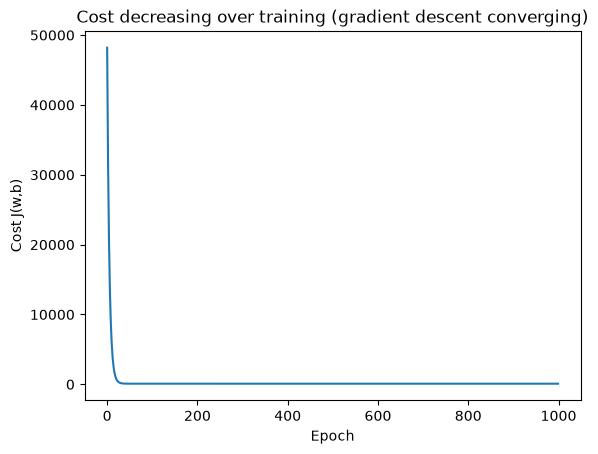

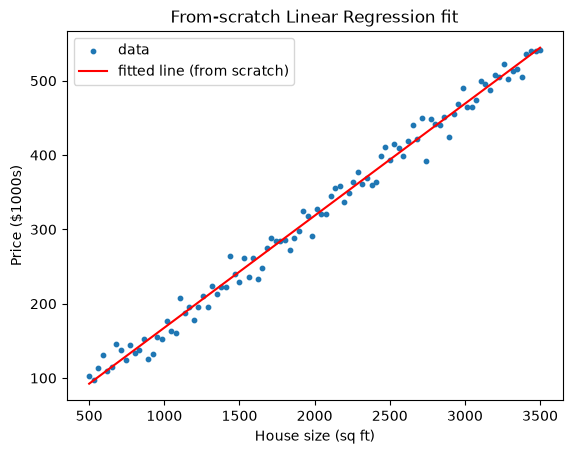

In [4]:
# Plot cost going down — proof gradient descent is working
plt.plot(cost_history)
plt.xlabel("Epoch")
plt.ylabel("Cost J(w,b)")
plt.title("Cost decreasing over training (gradient descent converging)")
plt.show()

# Plot fitted line over data
plt.scatter(X, y, s=10, label="data")
y_pred_line = w_final * X_norm + b_final
plt.plot(X, y_pred_line, color="red", label="fitted line (from scratch)")
plt.xlabel("House size (sq ft)")
plt.ylabel("Price ($1000s)")
plt.legend()
plt.title("From-scratch Linear Regression fit")
plt.show()

In [5]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_norm.reshape(-1, 1), y)

print("Sklearn:      w =", model.coef_[0], " b =", model.intercept_)
print("From scratch: w =", w_final, " b =", b_final)

Sklearn:      w = 131.812678127717  b = 318.4423022390886
From scratch: w = 131.8126781277169  b = 318.44230223908835
